In [1]:
import numpy as np
import pandas as pd
import os, sys
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from typing import Dict, List
from config import JUNCTIONS, get_file_paths, get_file_paths_list, reverse_complement
sys.path.append('../../pseudo_gene_maize/')
from get_logits import *

In [2]:
tokenizer = AutoTokenizer.from_pretrained('kuleshov-group/PlantCaduceus_l32')

In [3]:
labels_dict = {}
for idx, junction in enumerate(JUNCTIONS):
    label = pd.read_csv(get_file_paths('labels', '../../../results/pseudo_gene_tomato/splice_junctions/')[junction], sep='\t')
    for model in ['pcv1', 'pcv2_1', 'pcv2_2', 'pcv2_3']:
        predicted_codon, true_tokens = predicted_masked_tokens(model, idx, tokenizer, 
                                                               base_dir='../../../results/pseudo_gene_tomato/outputs', 
                                                               chunk_size=None, JUNCTIONS=JUNCTIONS)
        label[f'predicted_codon_{model}'] = predicted_codon
    label['true_tokens'] = true_tokens
    # for Evo2 fwd
    predicted_codon = pd.read_csv(get_file_paths('evo2_fwd', '../../../results/pseudo_gene_tomato/outputs')[junction], sep='\t', header=None)
    label['predicted_codon_evo2_fwd'] = predicted_codon[0]
    # for Evo2 rc
    predicted_codon = pd.read_csv(get_file_paths('evo2_rc', '../../../results/pseudo_gene_tomato/outputs')[junction], sep='\t', header=None)
    label['predicted_codon_evo2_rc'] = predicted_codon[0]
    label.loc[label['Label'].isin(['Shell', 'Cloud']), 'Label'] = 'Dispensable'
    labels_dict[junction] = label

In [4]:
labels_dict['start_sites'].head()

,Transcript_ID,Label,predicted_codon_pcv1,predicted_codon_pcv2_1,predicted_codon_pcv2_2,predicted_codon_pcv2_3,true_tokens,predicted_codon_evo2_fwd,predicted_codon_evo2_rc
0,Solyc00g005000.3,Core,AAT,ATG,ATG,ATG,ATG,AAA,AAA
1,Solyc00g005040.3,Core,GTT,ATG,ATT,ATG,ATG,ATT,CAT
2,Solyc00g005050.3,Core,ATG,ATG,ATG,ATG,ATG,AAA,CAT
3,Solyc00g005060.1,Dispensable,AGA,AGG,AGG,AGG,ATG,AGG,AGG
4,Solyc00g005080.2,Dispensable,AAA,AAA,AAA,AAA,AAA,TTT,TTT


In [5]:
labels_dict['start_sites']['Label'].value_counts()

Label
Core           29812
Softcore        3208
Dispensable     2464
Name: count, dtype: int64

In [6]:
label_order = ['Core', 'Softcore', 'Dispensable']
def calculate_accuracies(df, order=label_order):
    results = {}
    for label in order: 
        if label in df['Label'].values:
            group = df[df['Label'] == label].copy()
            
            # Calculate accuracy for PlantCAD models
            pcv1_acc = (group['predicted_codon_pcv1'] == group['true_tokens']).mean()
            pcv2_1_acc = (group['predicted_codon_pcv2_1'] == group['true_tokens']).mean()
            pcv2_2_acc = (group['predicted_codon_pcv2_2'] == group['true_tokens']).mean()
            pcv2_3_acc = (group['predicted_codon_pcv2_3'] == group['true_tokens']).mean()
            
            # Calculate accuracy for Evo2
            evo2_fwd_acc = (group['predicted_codon_evo2_fwd'] == group['true_tokens']).mean()
            group.loc[:, 'true_tokens_rc'] = group['true_tokens'].apply(reverse_complement)
            evo2_rc_acc = (group['predicted_codon_evo2_rc'] == group['true_tokens_rc']).mean()
            
            # Calculate combined accuracy
            evo2_either_acc = ((group['predicted_codon_evo2_fwd'] == group['true_tokens']) | 
                              (group['predicted_codon_evo2_rc'] == group['true_tokens_rc'])).mean()
            
            results[label] = {
                'pcv1': pcv1_acc,
                'pcv2_1': pcv2_1_acc,
                'pcv2_2': pcv2_2_acc,
                'pcv2_3': pcv2_3_acc,
                'evo2_fwd': evo2_fwd_acc,
                'evo2_rc': evo2_rc_acc,
                'evo2_either': evo2_either_acc
            }
    
    return results

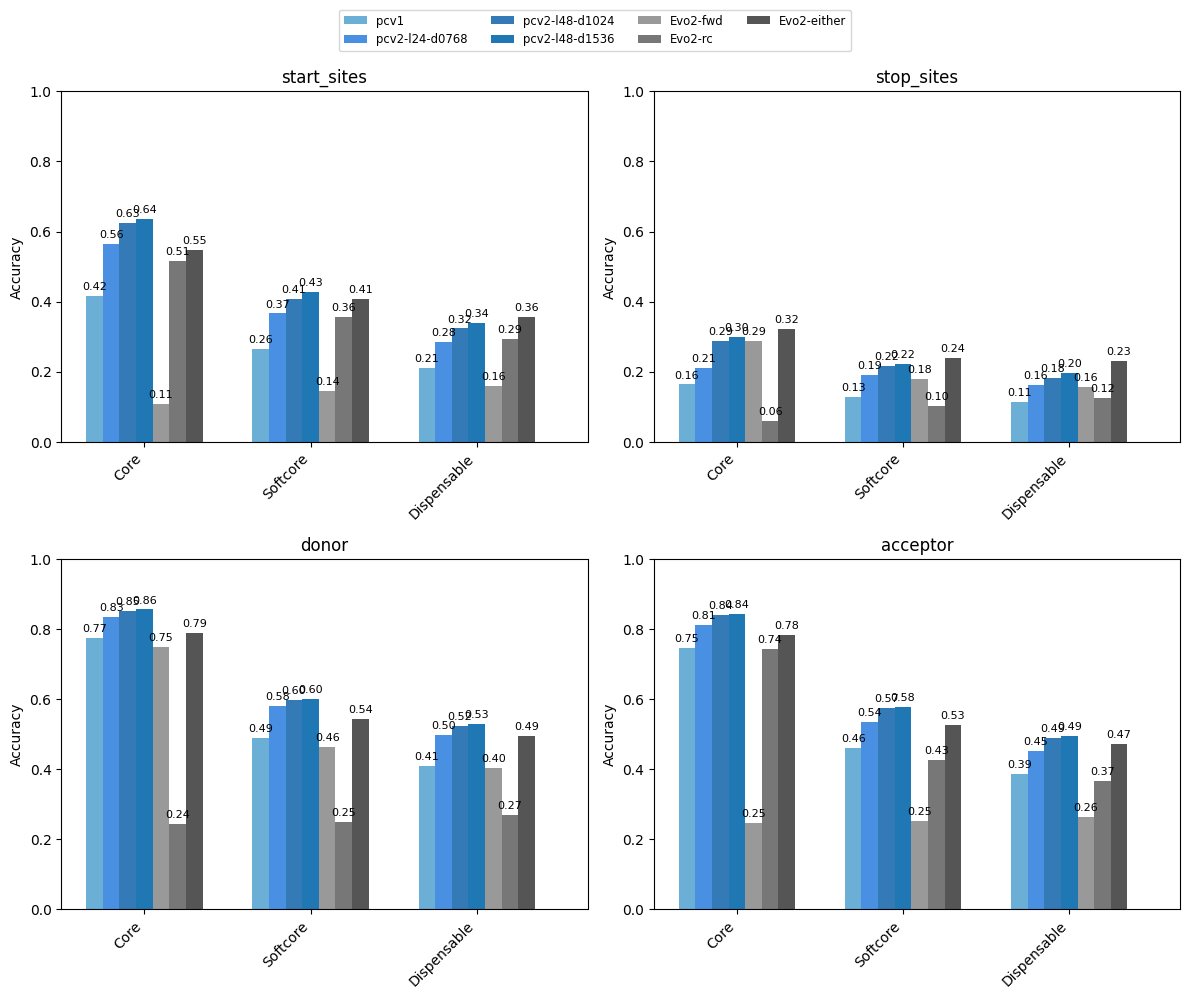

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes_flat = axes.flatten()
# Define distinct colors for different models
colors = ['#6baed6', '#4a90e2', '#337ab7', '#1f77b4', '#999999', '#777777', '#555555']

# Define models to plot (moved outside the loop)
models = ['pcv1', 'pcv2_1', 'pcv2_2', 'pcv2_3', 'evo2_fwd', 'evo2_rc', 'evo2_either']
labels = ['pcv1', 'pcv2-l24-d0768', 'pcv2-l48-d1024', 'pcv2-l48-d1536', 'Evo2-fwd', 'Evo2-rc', 'Evo2-either']

for idx, (dataset_name, df) in enumerate(labels_dict.items()):
    ax = axes_flat[idx]
    
    accuracies = calculate_accuracies(df)
    
    # Only include labels that exist in this dataset
    available_labels = [label for label in label_order if label in accuracies]
    
    # Define spacing parameters
    bar_width = 0.15  # Narrower bars
    group_padding = 0.5  # Adjustable space between gene classes
    
    # Create properly spaced group positions
    group_positions = np.arange(len(available_labels)) * (1 + group_padding)
    
    # Position of each bar within a group
    bar_positions = []
    for i in range(len(colors)):
        offset = i - (len(colors) - 1) / 2
        bar_positions.append(group_positions + offset * bar_width)
    
    # Create bars with spacing between groups
    rects_list = []
    for i, (model, label, color, positions) in enumerate(zip(models, labels, colors, bar_positions)):
        rects = ax.bar(positions, 
                      [accuracies[gene_label][model] for gene_label in available_labels], 
                      bar_width, label=label, color=color)
        rects_list.append(rects)
    
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{dataset_name}')
    ax.set_xticks(group_positions)
    ax.set_xticklabels(available_labels, rotation=45, ha='right')
    # Remove individual legends
    # ax.legend(loc='upper right', fontsize='small')
    ax.set_ylim(0, 1)
    
    # Set proper x-axis limits with padding
    ax.set_xlim(-0.5 * (1 + group_padding), 
                len(available_labels) * (1 + group_padding) - 0.5)
    
    # Add value labels on selected bars
    for rects in rects_list:
        for rect in rects:
            height = rect.get_height()
            if height > 0:  # Ensure labels are only placed for visible bars
                ax.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),  # Slightly higher for visibility
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=8)

# Create a single legend for the entire figure
# Place it at the top of the figure
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.0), 
           ncol=4, fontsize='small')

# Add more space at the top for the legend
plt.subplots_adjust(top=0.85)  # Adjust this value to fit your legend

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout but leave space for legend
plt.savefig('Token_accuracy_comparison.pdf', format='pdf', bbox_inches='tight')
plt.show()